In [1]:
from moabb.datasets import *
from moabb.paradigms import MotorImagery
from classification_mi import stf_transform, ZScore
import tensorly as tl
import numpy as np

dataset = AlexMI()
sfreq=250
paradigm = MotorImagery(resample=sfreq, n_classes=2)
epochs, y, meta = paradigm.get_data(dataset, return_epochs=True)
X = epochs.get_data()
groups=meta['subject']

select_idc = np.isin(y, ['right_hand', 'rest'])
X = X[select_idc]
y = y[select_idc]
groups = groups[select_idc]

X = stf_transform(X, n_freqs=32, downsample_factor=10)
X = tl.tensor(X)
X.shape

zscore = ZScore()
X = zscore.fit_transform(X)

Choosing from all possible events


Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
480 matching events found
No baseline correction applied


/usr/local/lib/python3.10/dist-packages/moabb/paradigms/base.py:392: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)


In [2]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.decomposition import PCA
from bttda.classification import SelectFCutoff, ZScore
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

clf =  make_pipeline(
        FunctionTransformer(tl.to_numpy),
        PCA(n_components=None, whiten=True),
        SelectFCutoff(cutoff=1),
        LinearDiscriminantAnalysis(shrinkage="auto", solver="lsqr"),
    )

In [3]:
from sklearn.model_selection import StratifiedGroupKFold
from bttda.classification import BTTDACV
from bttda.hoda import BTTDA

cv = StratifiedGroupKFold(n_splits=5)

hoda_params=  dict(
    max_iter=512,
    toeplitz=None,
    verbose=True,
)


bttdacv_params = dict(
    hoda_params=hoda_params,
    verbose=True,
    cv=cv,
    n_jobs=1,
    clf = clf,
)

bttdacv = BTTDACV(
    max_n_blocks=2,
    fixed_n_blocks=True,
    thetas=[0,0.1,0.2,0.3,0.4,0.5,0.6, 0.7, 0.8, 0.9,1],    
    **bttdacv_params
)

    

In [4]:
bttdacv.fit(X,y, groups=groups)

fold=0, theta=0
Fitting block 1/2...


Forward model :   2%|▏         | 8/511 [00:00<00:13, 36.88it/s]


Fitting block 2/2...


Forward model :  21%|██▏       | 109/511 [00:02<00:08, 47.65it/s]


fold=0, theta=0, n_blocks=2
fold=0, theta=0.1
Fitting block 1/2...


...

Fitting BTTDA with theta=0.7, n_blocks=2
Fitting block 1/2...


Forward model :  16%|█▋        | 84/511 [00:08<00:43,  9.92it/s]


Fitting block 2/2...


Forward model :  16%|█▋        | 84/511 [00:08<00:42, 10.09it/s]


BTTDACV(clf=Pipeline(steps=[('zscore', ZScore()),
                            ('functiontransformer',
                             FunctionTransformer(func=<function CupyBackend.to_numpy at 0x7fb1e1fe1bd0>)),
                            ('pca', PCA(whiten=True)),
                            ('selectfcutoff', SelectFCutoff()),
                            ('lineardiscriminantanalysis',
                             LinearDiscriminantAnalysis(shrinkage='auto',
                                                        solver='lsqr'))]),
        cv=StratifiedGroupKFold(n_splits=5, random_state=None, shuffle=False),
        fixed_n_blocks=True,
        hoda_params={'max_iter': 512, 'rank': None, 'taper': False,
                     'theta': np.float64(0.7), 'toeplitz': None,
                     'verbose': True},
        max_n_blocks=2,
        thetas=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1],
        verbose=True)

In [5]:
bttdacv.blocks_[0].theta

np.float64(0.7)

In [7]:
!mkdir -p notebooks/mi/results/interpretability

16

Automatic pdb calling has been turned ON
No baseline correction applied


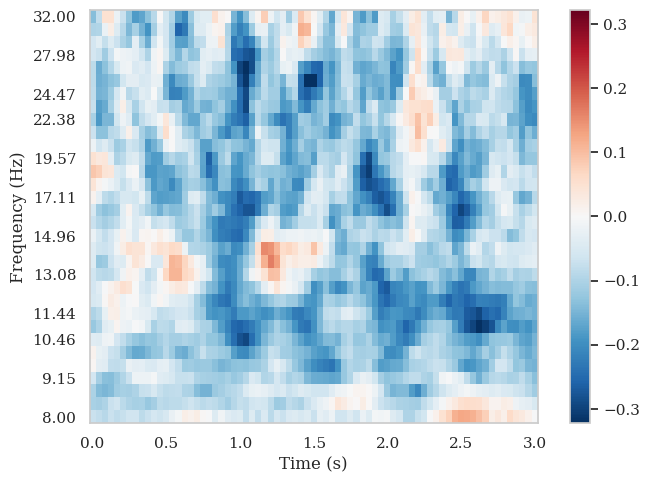

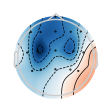

No baseline correction applied


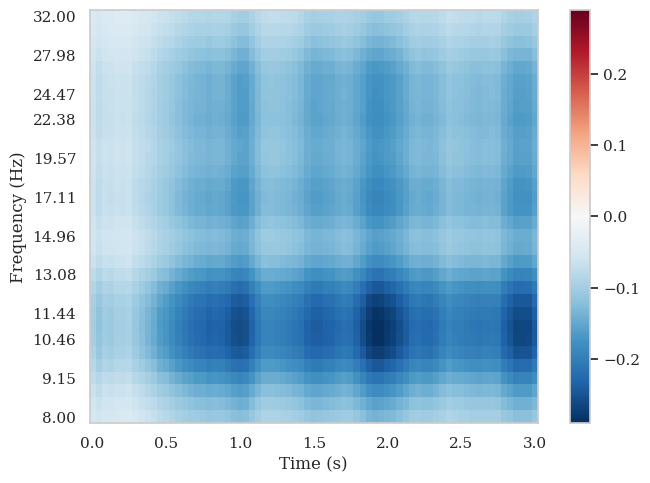

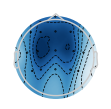

No baseline correction applied


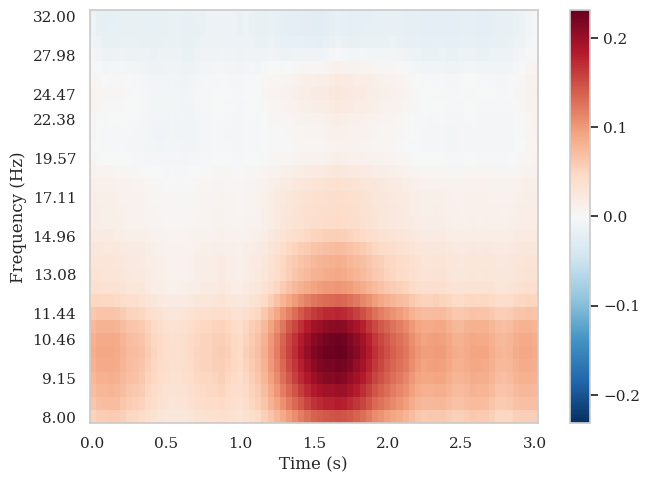

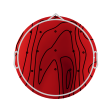

In [19]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import plotly.express as px
from mne.viz import plot_topomap
import seaborn as sns
import matplotlib.pyplot as plt
from mne.time_frequency import EpochsTFRArray
from mne import combine_evoked
from mne.channels import make_standard_montage
%matplotlib inline
%pdb on 
ch_idx = epochs.ch_names.index('C3')
freqs = np.geomspace(8, 32, 32)
times = np.linspace(epochs.times[0], epochs.times[-1], X.shape[-1])

roi = [
    dict(chan='C3', tmin=0.9, tmax=1.1, fmin=9, fmax=14),
    dict(chan='C3', tmin=1.3, tmax=2, fmin=9, fmax=14),
]

def viz_tfr(X, name, chan='C3', **topo_kwargs):    
    X = zscore.inv_transform(X)
    X = tl.to_numpy(X)
    epochs_tfr = EpochsTFRArray(epochs.info, X, times, freqs)
    montage = make_standard_montage('standard_1020')
    epochs_tfr.info.set_montage(montage)

    right_hand = epochs_tfr[y=='right_hand'].average()
    rest = epochs_tfr[y=='rest'].average()
    contrast = combine_evoked([right_hand, rest], weights=[1,-1])
    contrast.save(f'results/interpretability/mi_contrast_{name}_tfr.h5', overwrite=True)

    contrast.copy().pick('C3').plot()
    
    topo = contrast.crop(**topo_kwargs).data.mean(axis=(1,2))
    vlim = np.max(np.abs(topo))
    plot_topomap(topo, epochs.info, vlim=(-vlim, vlim))
    
viz_tfr(X, 'grand-avg')

X_prev = tl.zeros_like(X)
for bi,b in enumerate(bttdacv.blocks_):
    Xt = bttdacv.transform(X, n_blocks=bi+1)
    Xr = bttdacv.inv_transform(Xt, n_blocks=bi+1) - X_prev
    X_prev = Xr
    viz_tfr(Xr, f'block-{bi+1}',**roi[bi])

Xt = bttdacv.transform(X)
Xr = bttdacv.inv_transform(Xt)
#viz_tfr(Xr, 'reconstructed')
